install libs

In [34]:
try:
	from sklearn.preprocessing import StandardScaler
	from sklearn.decomposition import TruncatedSVD
except ImportError:
	%pip install -q scikit-learn
	from sklearn.preprocessing import StandardScaler
	from sklearn.decomposition import TruncatedSVD

### Read data from parquet files


In [35]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


# Define the directory containing the Parquet files
data_dir = os.path.join('data', 'iam_dataset')

# Read each Parquet file into a separate DataFrame
account_entitlements_df = pd.read_parquet(os.path.join(data_dir, 'account_entitlements.parquet'))
accounts_df = pd.read_parquet(os.path.join(data_dir, 'accounts.parquet'))
applications_df = pd.read_parquet(os.path.join(data_dir, 'applications.parquet'))
entitlement_group_assignments_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_assignments.parquet'))
entitlement_group_relations_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_group_relations.parquet'))
group_entitlements_df = pd.read_parquet(os.path.join(data_dir, 'group_entitlements.parquet'))
entitlement_groups_df = pd.read_parquet(os.path.join(data_dir, 'entitlement_groups.parquet'))
entitlements_df = pd.read_parquet(os.path.join(data_dir, 'entitlements.parquet'))
identities_df = pd.read_parquet(os.path.join(data_dir, 'identities.parquet'))
resources_df = pd.read_parquet(os.path.join(data_dir, 'resources.parquet'))

# Print the shapes of the DataFrames
print(f"Shape of account_entitlements_df: {account_entitlements_df.shape}")
print(f"Shape of accounts_df: {accounts_df.shape}")
print(f"Shape of applications_df: {applications_df.shape}")
print(f"Shape of entitlement_group_assignments_df: {entitlement_group_assignments_df.shape}")
print(f"Shape of entitlement_group_relations_df: {entitlement_group_relations_df.shape}")
print(f"Shape of entitlement_groups_df: {entitlement_groups_df.shape}")
print(f"Shape of entitlements_df: {entitlements_df.shape}")
print(f"Shape of identities_df: {identities_df.shape}")
print(f"Shape of resources_df: {resources_df.shape}")

Shape of account_entitlements_df: (972420, 5)
Shape of accounts_df: (314631, 6)
Shape of applications_df: (1000, 4)
Shape of entitlement_group_assignments_df: (170010, 3)
Shape of entitlement_group_relations_df: (571, 2)
Shape of entitlement_groups_df: (711, 5)
Shape of entitlements_df: (22991, 5)
Shape of identities_df: (50000, 8)
Shape of resources_df: (2100, 5)


## EDA

### Distribution of accounts per user

In [36]:
# Group by 'identity_id' and count the number of accounts for each user
accounts_per_user = accounts_df.groupby('identity_id').size()

# Get the distribution of the number of accounts
account_distribution = accounts_per_user.value_counts()

print("Distribution of accounts per user:")
print(account_distribution)

Distribution of accounts per user:
6     9966
5     9911
7     9010
4     8772
9     7904
8     4192
10     245
Name: count, dtype: int64


### Distribution of entitlements per account

Distribution of entitlements per account:
1     240438
2      24193
20      9012
13      7010
5       5027
12      4041
17      4025
9       3968
14      3964
19      3031
10      1967
15      1962
18      1943
6       1055
8       1026
16       998
7        971
Name: count, dtype: int64


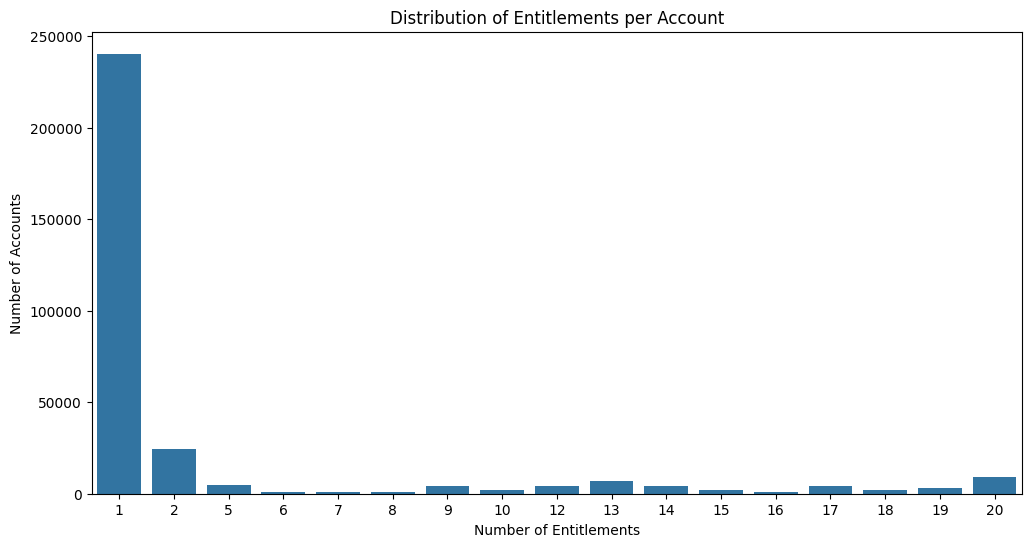

In [37]:


# --- Analysis for account_entitlements ---

# Group by 'account_id' and count the number of entitlements for each account
entitlements_per_account = account_entitlements_df.groupby('account_id').size()

# Get the distribution of the number of entitlements
entitlement_distribution = entitlements_per_account.value_counts()

print("Distribution of entitlements per account:")
print(entitlement_distribution)

# Create a bar plot of the entitlement distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_distribution.index, y=entitlement_distribution.values)
plt.xlabel("Number of Entitlements")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Entitlements per Account")
plt.show()




### Distribution of entitlement groups per identity:


Distribution of entitlement groups per identity:
3    31981
4    16028
5     1991
Name: count, dtype: int64


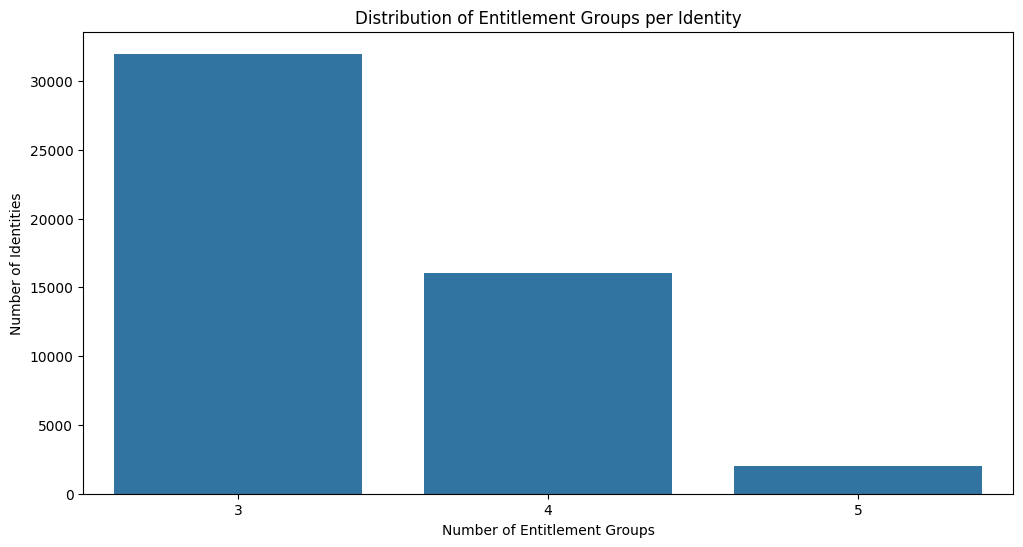

In [38]:
# --- Analysis for entitlement_group_assignments ---

# Group by 'identity_id' and count the number of entitlement groups for each identity
entitlement_groups_per_identity = entitlement_group_assignments_df.groupby('identity_id').size()

# Get the distribution of the number of entitlement groups
entitlement_group_distribution = entitlement_groups_per_identity.value_counts()

print("\nDistribution of entitlement groups per identity:")
print(entitlement_group_distribution)

# Create a bar plot of the entitlement group distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=entitlement_group_distribution.index, y=entitlement_group_distribution.values)
plt.xlabel("Number of Entitlement Groups")
plt.ylabel("Number of Identities")
plt.title("Distribution of Entitlement Groups per Identity")
plt.show()

### Columns in each entity

In [39]:
print("applications_df columns:", applications_df.columns)
print("resources_df columns:", resources_df.columns)
print("entitlements_df columns:", entitlements_df.columns)
print("account_entitlements_df columns:", account_entitlements_df.columns)
print("accounts_df columns:", accounts_df.columns)

applications_df columns: Index(['app_id', 'app_name', 'business_criticality', 'app_owner_id'], dtype='str')
resources_df columns: Index(['resource_id', 'app_id', 'iga_source_name', 'connection_type',
       'resource_type'],
      dtype='str')
entitlements_df columns: Index(['entitlement_id', 'resource_id', 'entitlement_name', 'is_requestable',
       'owner_id'],
      dtype='str')
account_entitlements_df columns: Index(['identity_id', 'account_id', 'entitlement_id', 'grant_date',
       'assignment_type'],
      dtype='str')
accounts_df columns: Index(['identity_id', 'resource_id', 'account_id', 'account_name',
       'is_privileged', 'status'],
      dtype='str')


### Distribution of resources per application

Distribution of resources per application:
1     640
2     203
3      28
4      48
5      20
6       9
7       2
8       6
9       1
10      8
11      4
12      5
13      6
14      9
15     11
Name: count, dtype: int64


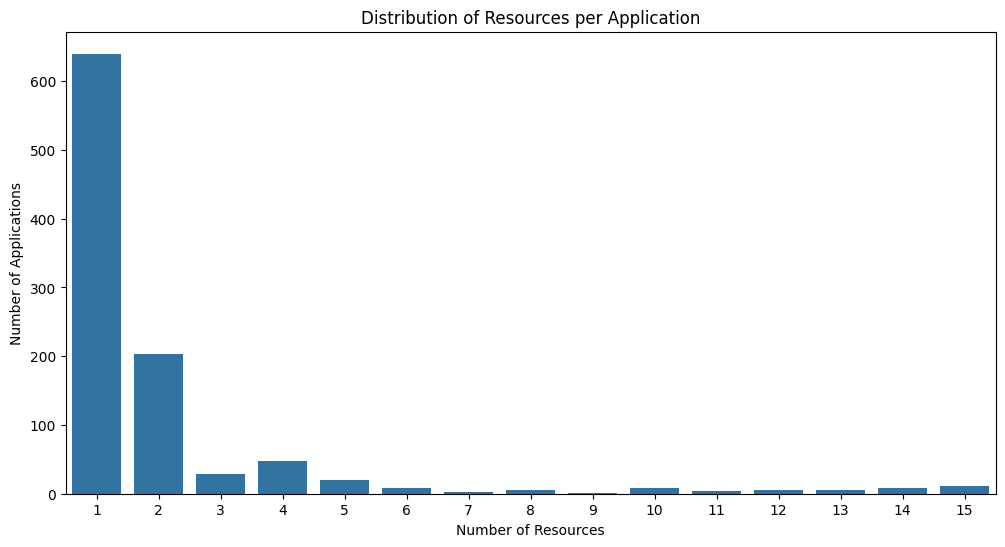

In [40]:
# --- Analysis for application to resource mapping ---

# Group by 'app_id' and count the number of resources for each application
resources_per_app = resources_df.groupby('app_id').size()

# Get the distribution of the number of resources
resource_distribution = resources_per_app.value_counts().sort_index()

print("Distribution of resources per application:")
print(resource_distribution)

# Create a bar plot of the resource distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_distribution.index, y=resource_distribution.values)
plt.xlabel("Number of Resources")
plt.ylabel("Number of Applications")
plt.title("Distribution of Resources per Application")
plt.show()

### Distribution of entitlements per resource

Distribution of entitlements per resource:
1      446
2      463
3      470
4       89
5       74
      ... 
454      1
459      1
460      1
469      1
474      1
Name: count, Length: 75, dtype: int64


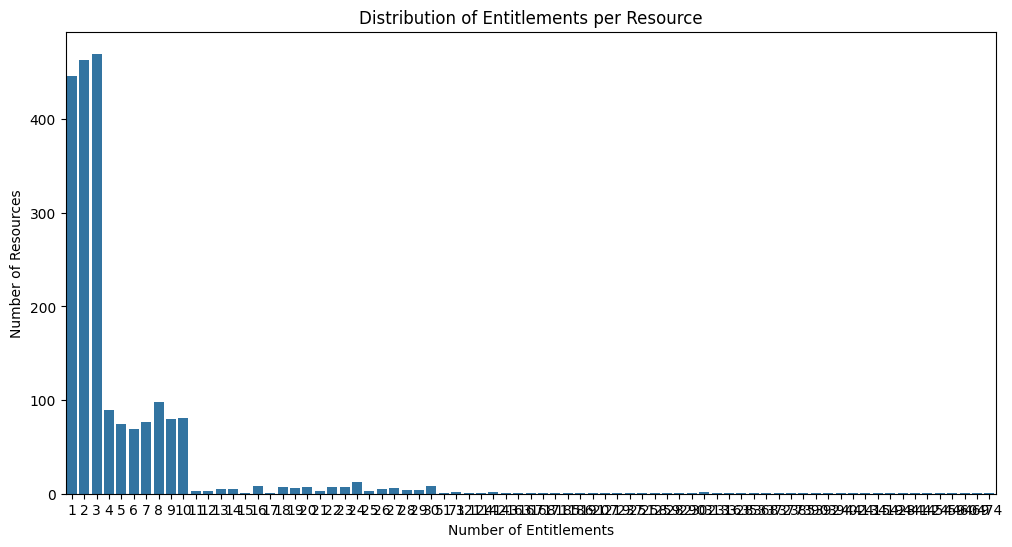

In [41]:
# --- Analysis for resource to entitlement mapping ---

# Group by 'resource_id' and count the number of entitlements for each resource
entitlements_per_resource = entitlements_df.groupby('resource_id').size()

# Get the distribution of the number of entitlements per resource
resource_entitlement_dist = entitlements_per_resource.value_counts().sort_index()

print("Distribution of entitlements per resource:")
print(resource_entitlement_dist)

# Create a bar plot of the resource to entitlement distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=resource_entitlement_dist.index, y=resource_entitlement_dist.values)
plt.xlabel("Number of Entitlements")
plt.ylabel("Number of Resources")
plt.title("Distribution of Entitlements per Resource")
plt.show()

### Distribution of accounts per entitlement:

Distribution of accounts per entitlement:
account_id
1       1077
2        128
3         22
4          3
939       12
        ... 
2018       1
2027       2
2032       1
2043       1
2947       1
Name: count, Length: 94, dtype: int64


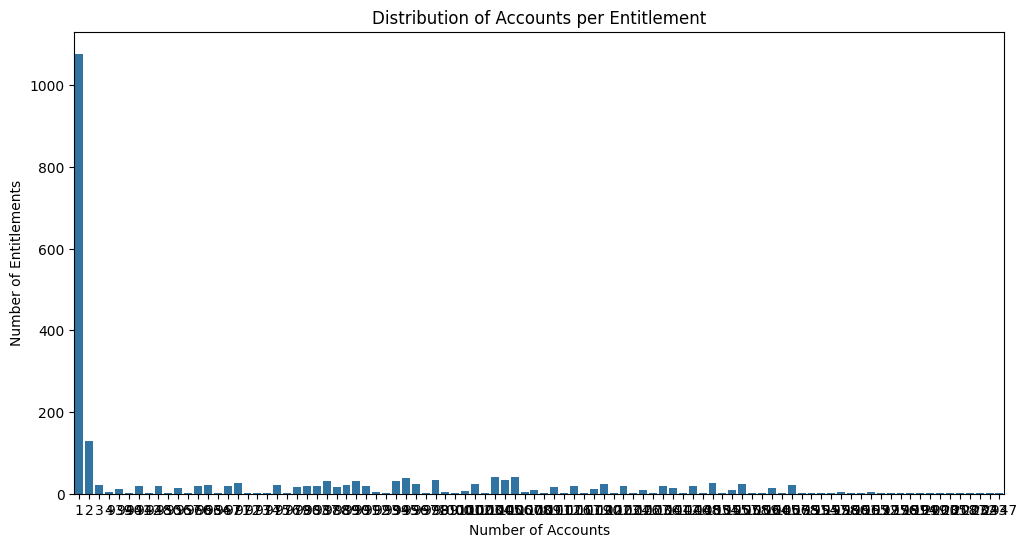

In [42]:
# --- Analysis for entitlement to account mapping ---

# Group by 'entitlement_id' and count the number of unique accounts for each entitlement
accounts_per_entitlement = account_entitlements_df.groupby('entitlement_id')['account_id'].nunique()

# Get the distribution of the number of accounts per entitlement
account_dist_per_entitlement = accounts_per_entitlement.value_counts().sort_index()

print("Distribution of accounts per entitlement:")
print(account_dist_per_entitlement)

# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=account_dist_per_entitlement.index, y=account_dist_per_entitlement.values)
plt.xlabel("Number of Accounts")
plt.ylabel("Number of Entitlements")
plt.title("Distribution of Accounts per Entitlement")
plt.show()

### Distribution of assignment counts per Entitlement Group

In [43]:
# Build pipeline inputs from loaded parquet data (run data-load cell first)
df_identities = identities_df.copy()
df_entitlements = entitlements_df.copy()

# User–entitlement mapping: merge account_entitlements with entitlements to get entitlement_name and risk_level
df_user_entitlements = (
    account_entitlements_df[['identity_id', 'entitlement_id']]
    .merge(entitlements_df[['entitlement_id', 'entitlement_name', 'risk_level']], on='entitlement_id', how='left')
    [['identity_id', 'entitlement_name', 'risk_level']]
    .drop_duplicates()
)
print("df_user_entitlements shape:", df_user_entitlements.shape)
df_user_entitlements.head()

KeyError: "['risk_level'] not in index"

Distribution of assignment counts per Entitlement Group:
30       1
33       2
34       2
35       2
36       2
        ..
5005     1
5018     1
5053     1
5084     1
50000    1
Name: count, Length: 134, dtype: int64


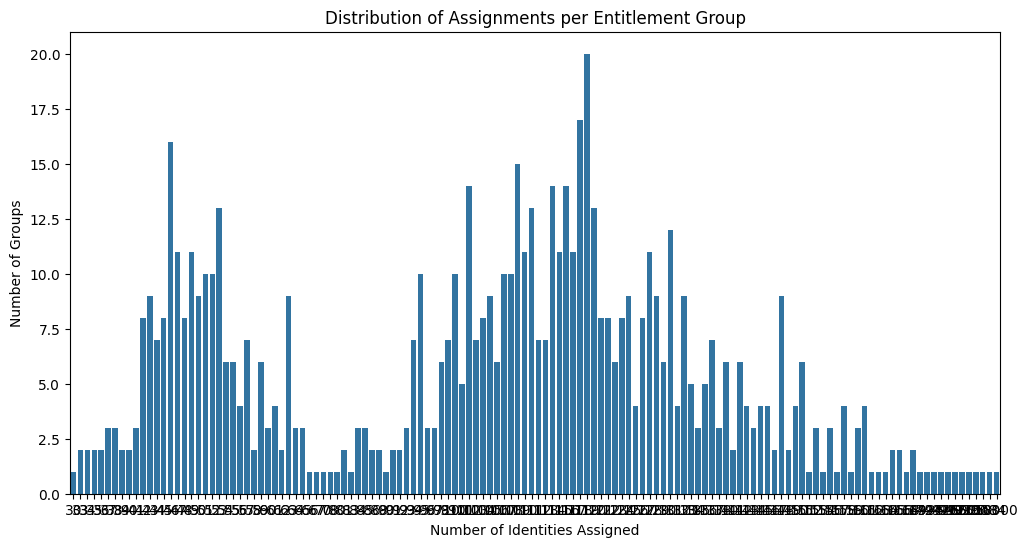

In [ ]:
# --- Analysis for entitlement group assignment distribution ---

# Group by 'ent_group_id' and count the number of identities assigned to each group
group_size = entitlement_group_assignments_df.groupby('ent_group_id').size()

# Get the distribution of the number of assignments
group_dist = group_size.value_counts().sort_index()

print("Distribution of assignment counts per Entitlement Group:")
print(group_dist)

# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=group_dist.index.astype(int), y=group_dist.values)
plt.xlabel("Number of Identities Assigned")
plt.ylabel("Number of Groups")
plt.title("Distribution of Assignments per Entitlement Group")
plt.show()

## Feature Engineering Pipeline for IAM Clustering

The following cells build a mathematical feature matrix from `df_identities`, `df_entitlements`, and `df_user_entitlements` (identity_id, entitlement_name, risk_level) for unsupervised peer-group clustering.

In [44]:
# --- Step 1: Contextual Feature Engineering (HR Data) ---
# Isolate active users (assume column 'status' with value 'Active'; adjust if your schema differs)
df_active = df_identities[df_identities['status'] == 'Active'].copy()

# One-Hot Encode department, job_title, location; set identity_id as index
df_features_hr = pd.get_dummies(
    df_active[['identity_id', 'department', 'job_title', 'location']],
    columns=['department', 'job_title', 'location'],
    dtype=int
).set_index('identity_id')

print("Step 1 — HR features shape:", df_features_hr.shape)
df_features_hr.head()

Step 1 — HR features shape: (45151, 23577)


,department_Customer Support,department_Engineering,department_Finance,department_HR,department_IT,department_Legal,department_Marketing,department_Operations,department_Product,department_Sales,...,location_Zimmermanshire,location_Zimmermanstad,location_Zimmermantown,location_Zoeberg,location_Zoeburgh,location_Zoeside,location_Zunigamouth,location_Zunigaside,location_Zunigaton,location_Zunigatown
identity_id,,,,,,,,,,,,,,,,,,,,,
2e420c0e-7360-4c03-abe2-184c794f6254,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
819ac6a0-8504-4823-802f-92fd6074096e,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1cb6f71e-27d6-430d-88c9-425d7d66ceb6,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5e73a201-388c-4860-944d-6a2a2e54bb6c,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7621e1ff-5766-406e-91c5-1579e76f376c,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
# --- Step 2: Behavioral Feature Engineering (User–Entitlement Sparse Matrix) ---
# Build binary User-Entitlement matrix: 1 if user holds entitlement, 0 otherwise
df_features_access = df_user_entitlements.assign(has_entitlement=1).pivot_table(
    index='identity_id',
    columns='entitlement_name',
    values='has_entitlement',
    aggfunc='max',
    fill_value=0
)

print("Step 2 — Access matrix shape:", df_features_access.shape)
df_features_access.iloc[:5, :5]

NameError: name 'df_user_entitlements' is not defined

In [ ]:
# --- Step 3: Aggregate Feature Creation ---
total_entitlements_count = df_user_entitlements.groupby('identity_id').size()

high_risk_entitlements_count = (
    df_user_entitlements
    .loc[df_user_entitlements['risk_level'].isin(['Critical', 'High'])]
    .groupby('identity_id')
    .size()
)

df_features_agg = pd.DataFrame({
    'total_entitlements_count': total_entitlements_count,
    'high_risk_entitlements_count': high_risk_entitlements_count
}).fillna(0).astype(int)

print("Step 3 — Aggregate features shape:", df_features_agg.shape)
df_features_agg.head()

Step 3 — Aggregate features shape: (50000, 2)


,total_entitlements_count,high_risk_entitlements_count
identity_id,,
00001d7d-2385-498c-b52b-5a4914cb8cff,25,1
0000f5b1-8747-4009-bbfd-1a0dfaab6187,20,0
0001d05a-2083-4d14-9ef0-a3b1d08c7f5d,18,5
00027fa9-6b32-4ee9-b0ee-793a16e63e94,13,0
0003ad37-19bf-4276-b345-4dd0e6602451,24,1


In [ ]:
# --- Step 4: Final Assembly & Scaling ---
# Concatenate HR, access, and aggregate features on identity_id index; fill NaNs with 0
df_master_feature_matrix = pd.concat(
    [df_features_hr, df_features_access, df_features_agg],
    axis=1,
    join='outer'
).fillna(0)

# Scale only aggregate numerical columns so they don't overpower binary columns
agg_cols = ['total_entitlements_count', 'high_risk_entitlements_count']
scaler = StandardScaler()
df_master_feature_matrix[agg_cols] = scaler.fit_transform(df_master_feature_matrix[agg_cols])

print("Step 4 — Master feature matrix shape:", df_master_feature_matrix.shape)
df_master_feature_matrix[agg_cols].describe()

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# --- Step 5: Dimensionality Reduction (TruncatedSVD) ---
n_components = 100
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_reduced = svd.fit_transform(df_master_feature_matrix)

print("Step 5 — Reduced matrix shape:", X_reduced.shape)
print("\nExplained variance ratio (first 100 components):")
print(svd.explained_variance_ratio_)
print("\nCumulative explained variance:", svd.explained_variance_ratio_.sum())